In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("insurance.csv")
copy = df.copy()

In [4]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.shape

(1338, 7)

In [8]:
target = df["charges"]

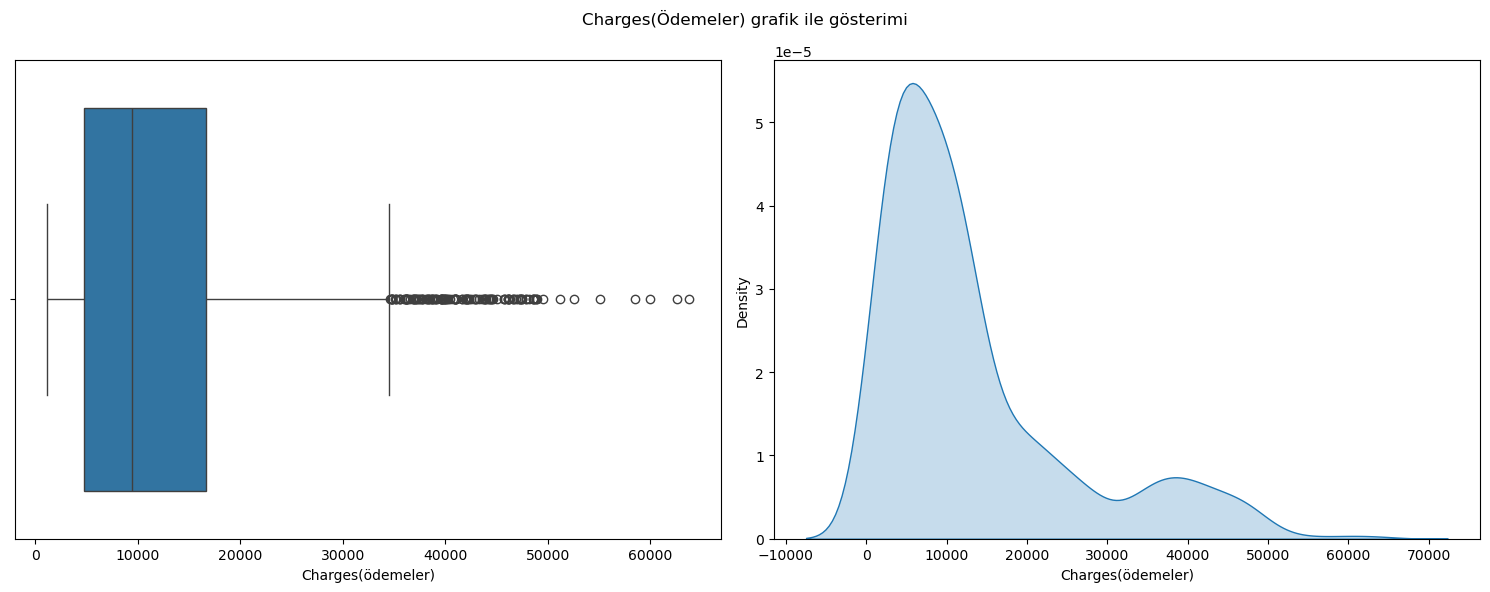

In [9]:
fig, ax = plt.subplots(1, 2, figsize = (15, 6))

sns.boxplot(
    data= df,
    x= "charges",
    ax= ax[0]
)

ax[0].set_xlabel("Charges(ödemeler)")

sns.kdeplot(
    data= df,
    x = "charges",
    fill= True,
    ax= ax[1]
)

ax[1].set_xlabel("Charges(ödemeler)")

plt.suptitle("Charges(Ödemeler) grafik ile gösterimi")
plt.tight_layout()
plt.show()

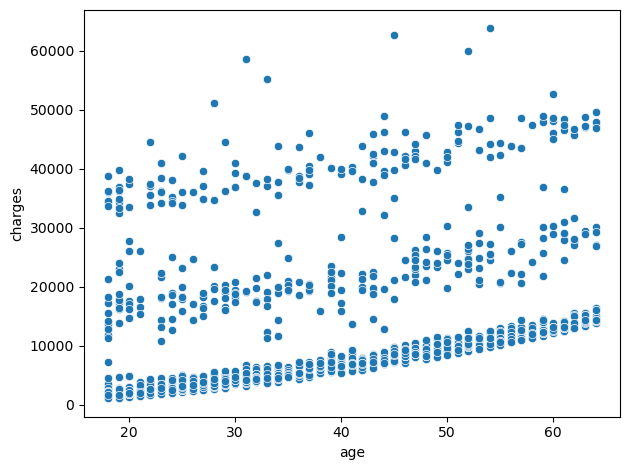

In [10]:
sns.scatterplot(
    data = df,
    y= "charges",
    x= "age"
)

plt.tight_layout()
plt.show()

In [11]:
age_groups = [17, 30, 45, 60, 65]
age_labels = ("18-30", "30-45", "45-60", "60+")

df["age_group"] = pd.cut(df["age"], bins= age_groups, labels= age_labels)


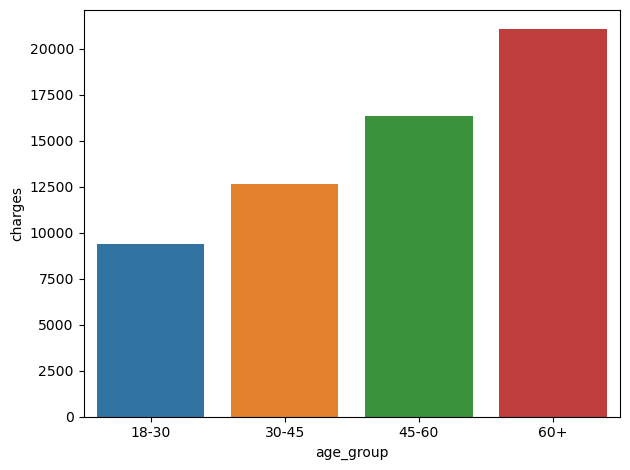

In [12]:
sns.barplot(
    data= df,
    x= "age_group",
    y= "charges",
    hue= "age_group",
    errorbar= None  
)


plt.tight_layout()
plt.show()

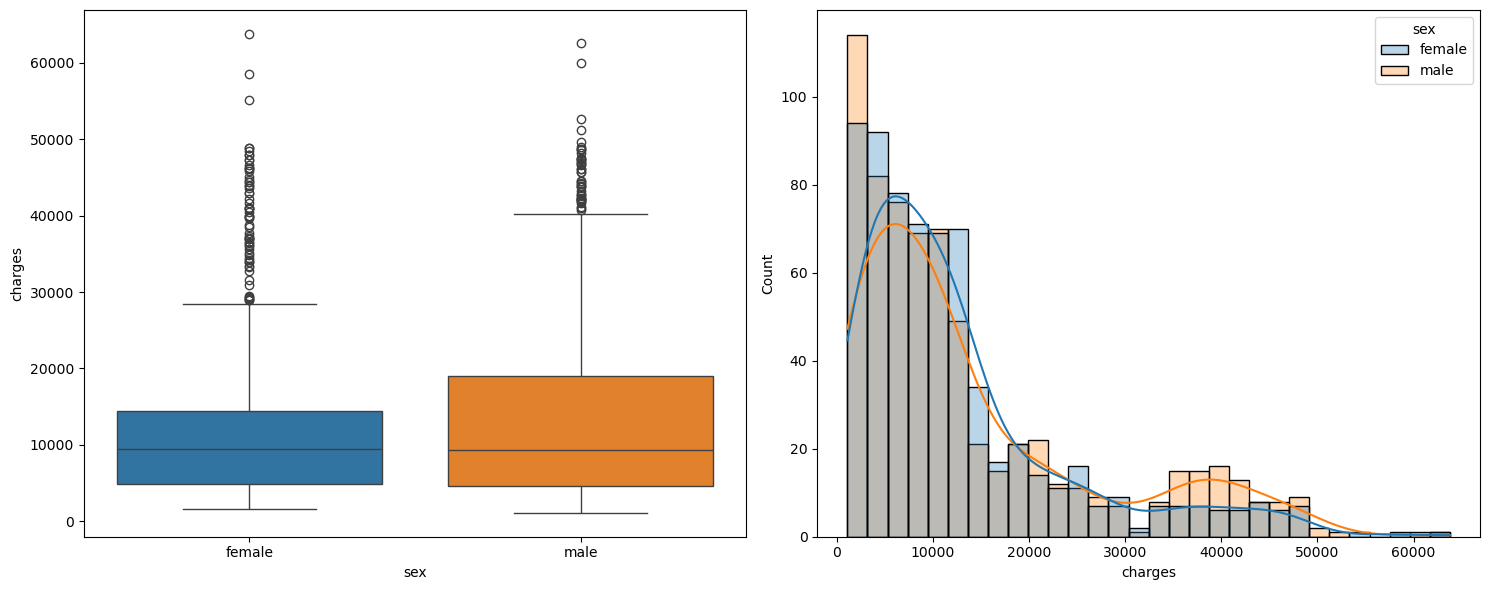

In [13]:
fig ,ax = plt.subplots(1, 2, figsize = (15, 6))

sns.boxplot(
    data= df,
    x= "sex",
    y= "charges",
    hue= "sex",
    ax= ax[0]
)

sns.histplot(
    data= df,
    x= "charges",
    hue= "sex",
    kde= True,
    alpha = 0.3,
    ax= ax[1]
)


plt.tight_layout()
plt.show()

In [14]:
bmi_bins = [0, 18.5, 25, 30, 40, float("inf")]
bmi_labels = ("Underweight", "Healty Weight", "Overiweight", "Obese", "Severely Obese")

df["bmi_group"] = pd.cut(df["bmi"], bins= bmi_bins, labels= bmi_labels)

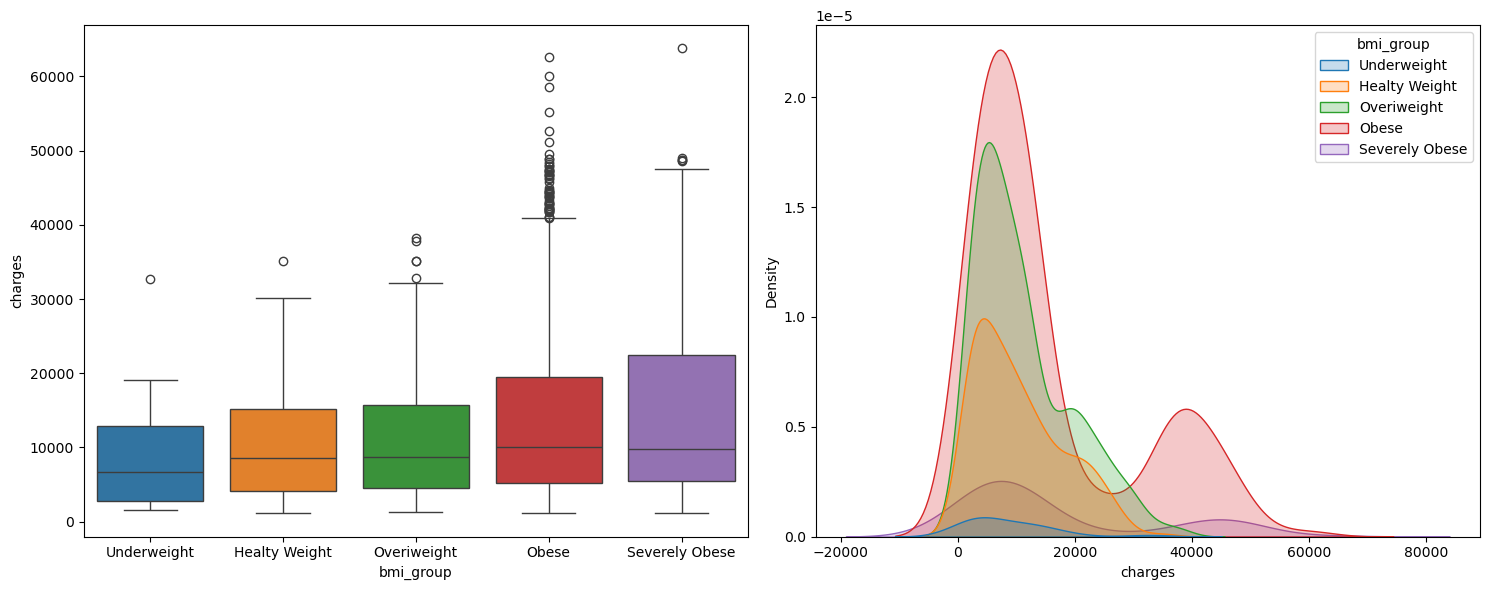

In [15]:
fig , ax = plt.subplots(1, 2, figsize = (15, 6))

sns.boxplot(
    data= df,
    x= "bmi_group",
    y= "charges",
    hue= "bmi_group",
    ax= ax[0]
)

sns.kdeplot(
    data= df,
    hue= "bmi_group",
    x= "charges",
    fill= True,
    ax= ax[1]
)

plt.tight_layout()
plt.show()

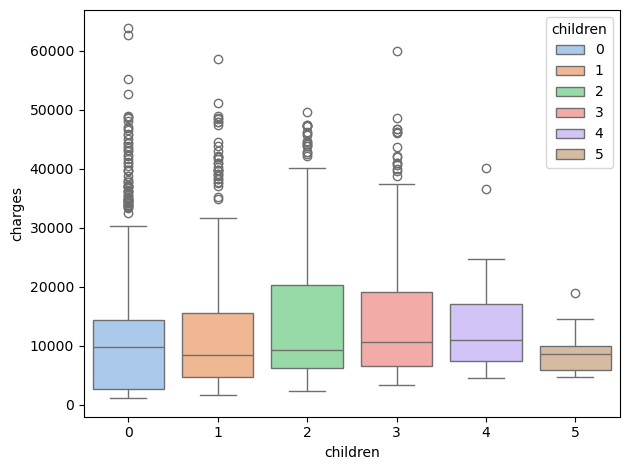

In [16]:
sns.boxplot(
    data= df,
    x= "children",
    y= "charges",
    hue= "children",
    palette= "pastel"
)

plt.tight_layout()
plt.show()

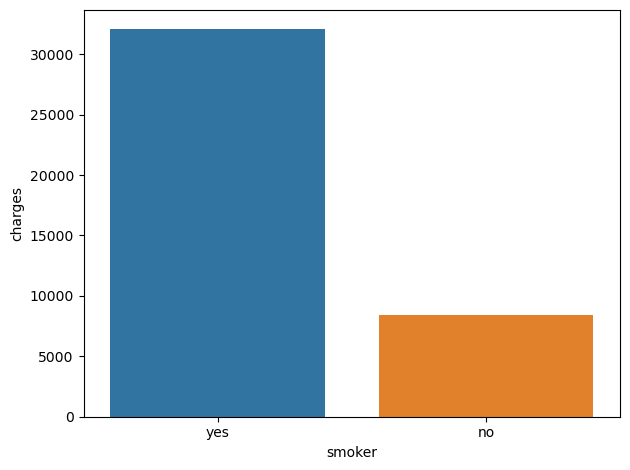

In [17]:
sns.barplot(
    data= df,
    x= "smoker",
    y= "charges",
    hue= "smoker",
    errorbar= None
)

plt.tight_layout()
plt.show()

<Axes: xlabel='region', ylabel='charges'>

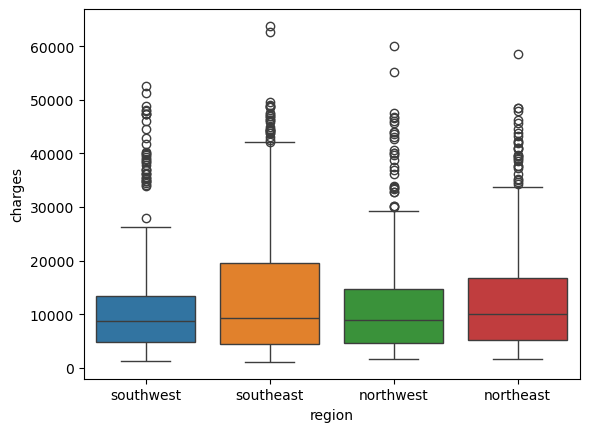

In [18]:
sns.boxplot(
    data= df,
    x= "region",
    y= "charges",
    hue= "region"
)

In [19]:
df.dtypes

age             int64
sex            object
bmi           float64
children        int64
smoker         object
region         object
charges       float64
age_group    category
bmi_group    category
dtype: object

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso, LassoCV
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.pipeline import Pipeline

from category_encoders import BinaryEncoder


In [21]:
scaler = StandardScaler()
regression = LinearRegression()
lasso, lassocv = Lasso(), LassoCV()
ridge, ridgecv = Ridge(), RidgeCV()
elastic, elasticcv = ElasticNet(), ElasticNetCV()

In [22]:
y = df['charges']
X = df[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 15)

In [23]:
# binary_encoder = BinaryEncoder(cols=["sex", "smoker"])
oneHot = OneHotEncoder(drop= "first", handle_unknown= "ignore", sparse_output= False)

# X_train = binary_encoder.fit_transform(X_train)
# X_test = binary_encoder.transform(X_test)

oneHot.fit(X_train[["region", "sex", "smoker"]])

train_encoded = oneHot.transform(X_train[["region", "sex", "smoker"]])
test_encoded = oneHot.transform(X_test[["region", "sex", "smoker"]])


In [24]:
train_region_df = pd.DataFrame(
    data= train_encoded,
    columns= oneHot.get_feature_names_out(["region", "sex", "smoker"])
)

test_region_df = pd.DataFrame(
    data= test_encoded,
    columns= oneHot.get_feature_names_out(["region", "sex", "smoker"])
)

In [25]:
X_train = X_train.drop(labels= ["region", "sex", "smoker"], axis= 1)
X_test = X_test.drop(labels= ["region", "sex", "smoker"], axis= 1)

X_train = pd.concat([X_train.reset_index(drop=True), train_region_df], axis=1)
X_test = pd.concat([X_test.reset_index(drop=True), test_region_df], axis=1)

In [26]:
X_train

,age,bmi,children,region_northwest,region_southeast,region_southwest,sex_male,smoker_yes
0,18,33.880,0,0.0,1.0,0.0,0.0,0.0
1,44,26.410,0,1.0,0.0,0.0,0.0,0.0
2,26,17.670,0,1.0,0.0,0.0,1.0,0.0
3,58,28.215,0,1.0,0.0,0.0,0.0,0.0
4,45,23.560,2,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
931,20,24.420,0,0.0,1.0,0.0,0.0,1.0
932,40,32.775,2,1.0,0.0,0.0,0.0,1.0
933,48,24.420,0,0.0,1.0,0.0,1.0,1.0
934,44,22.135,2,0.0,0.0,0.0,1.0,0.0


In [ ]:
# models = (regression, lasso, lassocv, ridge, ridgecv, elastic, elasticcv)

def pipeLine(X_train, y_train):
    models = (regression, lasso, lassocv, ridge, ridgecv, elastic, elasticcv)

    for model in models:
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])
        pipeline.fit(X_train, y_train)

        score = pipeline.score(X_test, y_test)

        print(f"Model : {model.__class__.__name__}\n\n" +
          f"R2 Score : {score}\n")
        
        print(f"Model Coefficients : {model.coef_}")
        
        print("=" * 50)



    
pipeLine(X_train, y_train)

Model : LinearRegression

R2 Score : 0.786647458274232

Model Coefficients : [3681.63461001 2041.10417446  648.36347993 -109.70063589 -481.37428132
 -422.45921983  -10.7066087  9459.78179197]
Model : Lasso

R2 Score : 0.7866467808840553

Model Coefficients : [3680.84079984 2039.5842718   647.46507761 -106.67484444 -477.87029118
 -419.2444838    -9.60167524 9458.61022508]
Model : LassoCV

R2 Score : 0.7864019376420576

Model Coefficients : [3577.47791254 1867.39458384  542.73262871    0.         -188.08396911
 -161.61326535    0.         9324.86108853]
Model : Ridge

R2 Score : 0.7866384128233882

Model Coefficients : [3677.29123365 2038.77609014  648.24741697 -109.22813482 -479.14949877
 -421.2950539    -9.55303695 9449.12725217]
Model : RidgeCV

R2 Score : 0.7866384128233748

Model Coefficients : [3677.29123365 2038.77609014  648.24741697 -109.22813482 -479.14949877
 -421.2950539    -9.55303695 9449.12725218]
Model : ElasticNet

R2 Score : 0.6917751617260011

Model Coefficients : [236

In [28]:
def poly_pipeline(degree):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree= degree)),
        ("model", LassoCV())
    ])
    pipeline.fit(X_train, y_train)

    score = pipeline.score(X_test, y_test)
    
    print(f"Degree : {degree}\n\n" +
          f"R2 Score :{score} ")
    print("="* 30)
    
degrees = np.arange(1, 6)

for degree in degrees:
    poly_pipeline(degree)

Degree : 1

R2 Score :0.7864019376420576 
Degree : 2

R2 Score :0.869947048216558 
Degree : 3

R2 Score :0.8742004026309583 
Degree : 4

R2 Score :0.875957475208094 
Degree : 5

R2 Score :0.8796620430839844 
